# Spatial · single-field — **sim vs theory** reference

The spatial twin of [`template_temporal_single_sim_compare.ipynb`](template_temporal_single_sim_compare.ipynb).  Identical `daedalus` core — the only differences are the simulator (`models.spatial_field_1d_sim`) and that the `sim` dict carries `{x, C, C_err}` (a spatial slice) instead of `{tau, C, C_err}`.  `dd.plot_cumulant` dispatches on the model and draws the equal-time `C(χ, 0)` overlay automatically.

## 1. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
import daedalus as dd
from models.spatial_field_1d_sim import simulate, equal_time_correlator
print('daedalus \u2192', dd.REPO_ROOT)

daedalus → /Users/matthewszuromi/Documents/Education/BU PhD/Ocker Lab/Automated Feynman Calculations


## 2. Theory side (identical to the plain template)

In [2]:
THEORY = 'allen_cahn_1d_subcritical_infinite'   # plain cubic vertex,
                                                # tree ⟨φ²⟩ = 0.5

cfg = dd.Config(
    k=2,
    max_ell=1,                  # tree + 1-loop tadpole
    chi_grid=(0.0, 5.0, 26),
    tau_max=0.0,                # equal-time slice
    fundamental={'lam': 0.3},   # bump the cubic coupling for a visible loop
    show_orders='cumulative',
)

model, mod = dd.load_theory(THEORY)
res = dd.run(model, cfg, mod)
print(dd.summary(res))

theory : '1D stochastic Allen-Cahn (subcritical, infinite domain)'
k      : 2    max_ell : 1
fields : ['dphi']   spatial_dim : 1
diagrams (live): 1


## 3. Simulation side (matched parameters)

Pull the parameters the theory used out of `res['_resolved']['fundamental']`, run a few Euler–Maruyama trajectories of the same SPDE, and form the periodic equal-time correlator `C(χ) = ⟨φ(x₀) φ(x₀+χ)⟩`.  Output is a plain `{x, C, C_err}` dict.

In [3]:
fund = res['_resolved']['fundamental']
mu, D, lam, T = (float(fund['mu']), float(fund['D']),
                 float(fund['lam']), float(fund['T']))

L, N = 20.0, 128            # box length, lattice sites
x_hi = float(np.max(np.asarray(res['spatial_grid'])))

C_runs = []
t0 = time.perf_counter()
for seed in (7, 8, 9):
    snaps, _xs, meta = simulate(
        L=L, N=N, mu=mu, D=D, lam=lam, T=T,
        dt=0.02, n_steps=60_000, burn_in=8_000,
        record_every=10, seed=seed)
    C_runs.append(equal_time_correlator(snaps))   # length N (separation)
dx = meta['dx']
C_runs = np.array(C_runs)

sep  = np.arange(N) * dx
keep = sep <= x_hi
sim = {
    'x':     sep[keep],
    'C':     C_runs.mean(axis=0)[keep],
    'C_err': (C_runs.std(axis=0, ddof=1) / np.sqrt(len(C_runs)))[keep],
}
_i0 = int(np.argmin(np.abs(np.asarray(res['spatial_grid']))))
print(f'sim: {len(C_runs)} seeds in {time.perf_counter()-t0:.1f}s')
print(f'  sim    C(0,0) = {sim["C"][0]:.4f}')
print(f'  theory C(0,0) = {float(np.real(res["C_tau_x"])[_i0, 0]):.4f}  (tree + {cfg.max_ell}-loop)')

sim: 3 seeds in 4.7s
  sim    C(0,0) = 0.4261
  theory C(0,0) = 0.3875  (tree + 1-loop)


## 4. Theory vs simulation

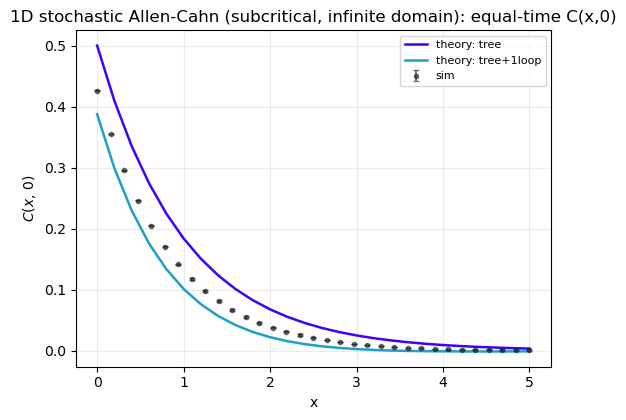

In [4]:
fig = dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()